In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional,Tuple,Dict
from __future__ import annotations

In [2]:
def find_tesis_root(start:Path |None = None, marker:str = "Results")-> Path:
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / "Results").exists():
            return parent
    raise FileNotFoundError("Results forlder not found")

TESIS_ROOT = find_tesis_root()

In [3]:
Results_Root = TESIS_ROOT / "Results"
colmap = {
    "t": "Time in s",
    "f": "Electrical Frequency in Hz",
    "V": "Voltage, Magnitude in p.u.",
    "w_eqsg": "Speed in p.u.",
    "P":"Active Power in MW",
    "Q":"Reactive Power in Mvar",
    "Ipos": "Positive-Sequence Current, Magnitude in p.u.",
}




In [4]:
# HELPERS

def load_pf_csv(path: str,colmap) -> pd.DataFrame:
    """
    Load a CSV exported by PowerFactory
    """
    df = pd.read_csv(path)
    df.columns = df.iloc[0]
    df = df.iloc[1:].reset_index(drop = True)
    #colmap = resolve_colmap(df,colmap)
    df = prepare_df(df,colmap)
    return df

def prepare_df(df:pd.DataFrame,colmap:dict)-> pd.DataFrame:
    for k,col in colmap.items():
        if col in df.columns:
            df[col] = pd.to_numeric(df[col],errors = "coerce")
    return df

def get_series(df: pd.DataFrame, colmap:Dict[str,str], key:str)-> pd.Series:
    """
    Receives a Dataframe in order to search for the column
    Colmap is a dictionary, where the mapping of the desired variable with the 
        respective column will happen i.e. in Dict {f:Electrical frequency}
        I search for the key "f"
    key: name of the variable i want to search for
    """
    if key not in colmap:
        raise KeyError(f"Missing key: {key} in colmap")
    col = colmap[key]
    if col not in df.columns:
        print(f"Column {col} not found in the CSV")
        print(f"Available columns: {df.columns}")
    return df[col]
    

def window_mask(t:np.ndarray,t0:float,t1:float) -> np.ndarray:
    return(t >= t0) & (t<=t1)

def finite_diff_derivative(t: np.ndarray, y:np.ndarray) ->np.ndarray:

    """
    This function calculates the derivative dy/dt
    Return an array of the same length of y
    """
    dydt = np.gradient(y,t)
    return dydt

def plot_signal_with(t,y,reference = 50,nadir = None,t_event = None,band = None,settling_time = None, title = "Signal",
                     y_label = "Value",label:str ="label"):
    plt.figure(figsize=(8,4))
    plt.plot(t,y,label = label)

    if nadir is not None:
        plt.axhline(nadir,linestyle="--",label = f"freq. nadir: {nadir} Hz",linewidth=0.7)
    
    if reference is not None:
        plt.axhline(reference + band, linestyle=":", color="gray",linewidth = 0.7)
        plt.axhline(reference - band, linestyle=":", color="gray",linewidth = 0.7)

    plt.axvline(settling_time, linestyle="--", linewidth=0.7)
    plt.xlabel("Time [s]")
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_signal(x,y,title:str = "Signal",y_label:str = "y label",label:str ="label"):
    plt.figure(figsize=(8,4))
    plt.plot(x,y,label = label)
    plt.xlabel("Time [s]")
    plt.xlim(0,20)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_signal_from_df(df,colmap,x:str,y:str,title:str = "Title",y_label:str = "y_label",label:str ="label"):
    plt.figure(figsize=(8,4))
    x_col  = colmap[x]
    y_col = colmap[y] 
    x = df[x_col]
    y = df[y_col]
    plt.plot(x,y,label = label)
    plt.xlabel(x_col)
    plt.xlim(0,20)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def load_all_results(results_root: str | Path,
                      colmap) -> Dict[Tuple[str, str], pd.DataFrame]:
    """
    Walks a Results folder with structure:
      Results/
        <TECH>/
          <CASE>/
            <CASE>.csv 

    Returns:
      dict keyed by (tech_name, case_name) -> DataFrame
    """
    results_root = Path(results_root)
    if not results_root.exists():
        raise FileNotFoundError(f"Results root not found: {results_root}")

    out: Dict[Tuple[str, str], pd.DataFrame] = {}

    tech_dirs = [p for p in results_root.iterdir() if p.is_dir()]
    for tech_dir in tech_dirs:
        if not tech_dir.is_dir():
            continue
        case_dirs = tech_dir.iterdir()
        for case_dir in case_dirs:
            if not case_dir.is_dir():
                continue
            tech_name = tech_dir.name
            case_name = case_dir.name
            for csv_path in case_dir.glob("*.csv"):
                df = load_pf_csv(csv_path,colmap)
                out[(tech_name,case_name)] = df
    return out


In [5]:
#LOAD STEP
def to_10Hz_reporting_rate(df):
    df_copy = df.copy()
    df_100ms = df_copy[::100]
    return df_100ms
   

def kpi_f_nadir(df, colmap, t0: float, t1: float ) -> float:
    t= get_series(df,colmap,"t").to_numpy()
    f = get_series(df,colmap,"f").to_numpy()
    m = window_mask(t, t0, t1)
    return float(f[m].min())
 

def kpi_rocof(df,colmap)-> float:
    t=get_series(df,colmap,"t").to_numpy()
    f=get_series(df,colmap,"f").to_numpy()
    rocof = np.diff(f)/np.diff(t)
    max_rocof = np.max(np.abs(rocof))
    t_rocof = t[1:]
    return max_rocof,rocof,t_rocof

def kpi_rocof_sliding(df,colmap,window_s=0.5):
    f = get_series(df,colmap,"f")
    t = get_series(df,colmap,"t")
    f = np.asarray(f)
    t = np.asarray(t)
    dt = np.mean(np.diff(t))     
    w = int(round(window_s / dt))  
    rocof = (f[w:] - f[:-w]) / (t[w:] - t[:-w])
    rocof_max = np.max(np.abs(rocof))
    t_rocof = (t[w:] + t[:-w]) / 2  

    return rocof_max,rocof,t_rocof


def kpi_f_setlting_time(df,colmap,band:float = 0.01,t_event:float =1):
    def get_fss_for_settling_time(df,colmap,t_end: float,                   
    tail_s: float = 3.0,          # last N seconds used to judge steady state
    ripple_thr_hz: float = 0.02,  # max peak-to-peak ripple allowed in tail
    drift_thr_hz: float = 0.005,  # max mean-drift between halves of tail
    stat: str = "mean",           # "mean" or "median" for f_ss
    ):
        """
        Decide if frequency has settled at the end of the simulation and estimate f_ss.

        Logic :
        1) Take tail window [t_end - tail_s, t_end]
        2) Compute ripple = max(f) - min(f) in tail
        3) Compute drift = |mean(second half) - mean(first half)|
        4) Settled if ripple <= ripple_thr_hz AND drift <= drift_thr_hz
        5) If settled: f_ss = mean/median over the tail window; else return None

        Returns
        -------
        settled : bool
        f_ss : float | None
        info : dict   (useful for debugging / reporting)
        """
        t = get_series(df, colmap, "t").to_numpy()
        f = get_series(df, colmap, "f").to_numpy()

        # Tail window mask
        t0 = t_end - tail_s
        m_tail = window_mask(t, t0, t_end)
        tt = t[m_tail]
        ff = f[m_tail]
        

        # Basic checks
        if len(tt) < 5:
            print(f"reason too_few_samples_in_tail: n =  {int(len(tt))}")
            return False

        # Drop NaNs
        ok = np.isfinite(tt) & np.isfinite(ff)
        tt, ff = tt[ok], ff[ok]
        if len(tt) < 5:
            return False, None, {"reason": "too_many_nans_in_tail", "n": int(len(tt))}

        # Ripple (peak-to-peak) in tail
        ripple = float(np.max(ff) - np.min(ff))

        # Drift between first and second half of tail (simple drift test)
        t_mid = tt[0] + 0.5 * (tt[-1] - tt[0])
        m1 = tt <= t_mid
        m2 = tt > t_mid
        if m1.sum() < 2 or m2.sum() < 2:
            return False, None, {"reason": "tail_split_failed", "n": int(len(tt))}
        mean1 = float(np.mean(ff[m1]))
        mean2 = float(np.mean(ff[m2]))
        drift = float(abs(mean2 - mean1))

        settled = (ripple <= ripple_thr_hz) and (drift <= drift_thr_hz)

        if not settled:
            info = {
                "tail_start": float(t0),
                "tail_end": float(t_end),
                "ripple_hz": ripple,
                "drift_hz": drift,
                "mean1_hz": mean1,
                "mean2_hz": mean2,
            }
            return 50

        # Steady-state estimate
        if stat == "mean":
            f_ss = float(np.mean(ff))
        elif stat == "median":
            f_ss = float(np.median(ff))
        else:
            raise ValueError("stat must be 'mean' or 'median'")
        flag = True
        info = {
            "tail_start": float(t0),
            "tail_end": float(t_end),
            "ripple_hz": ripple,
            "drift_hz": drift,
            "f_ss_hz": f_ss,
        }
        return  f_ss
    # Create band
    def create_band(fss:float):
        f_low = float(fss-band) 
        f_high = float(fss+band)
        return f_low,f_high
    fss = get_fss_for_settling_time(df,colmap,20,3,0.01,0.005,"mean")
    f_low,f_high =create_band(fss)
    print(f"Frequency band [{f_low},{f_high}]")
    t = get_series(df,colmap,"t").to_numpy()
    f=get_series(df,colmap,"f").to_numpy()
    mask = t >= t_event
    tt = t[mask]
    ff = f[mask]
    ok = np.isfinite(tt) & np.isfinite(ff)
    tt, ff = tt[ok], ff[ok]
    inside = (ff >= f_low) & (ff <= f_high)
    for i in range(len(tt)):
        if inside[i] and inside[i:].all():
            Ts = float(tt[i]-t_event)
            break
    return Ts,fss
     

def kpi_f_overshoot(df, colmap, t_event: float, T: float = 10.0) -> float:
    t = get_series(df, colmap, "t").to_numpy()
    f = get_series(df, colmap, "f").to_numpy()
    m = window_mask(t, t_event, t_event + T)
    return float(f[m].max())

def kpi_delta_fss(fss):
    return round(float(fss-50),4)


def kpi_delta_P(df,colmap,t_event):
    def get_Pss_for_deltaP(df,colmap,t_end: float,
    tail_s: float = 3.0,          # last N seconds used to judge steady state
    ripple_thr_P: float = 0.1,  # max peak-to-peak ripple allowed in tail
    drift_thr_P: float = 0.05,  # max mean-drift between halves of tail
    stat: str = "mean",           # "mean" or "median" for f_ss
    ):
        """
        Decide if Power  has settled at the end of the simulation and estimate P_ss.

        Logic :
        1) Take tail window [t_end - tail_s, t_end]
        2) Compute ripple = max(f) - min(f) in tail
        3) Compute drift = |mean(second half) - mean(first half)|
        4) Settled if ripple <= ripple_thr_hz AND drift <= drift_thr_hz
        5) If settled: f_ss = mean/median over the tail window; else return None

        Returns
        -------
        settled : bool
        f_ss : float | None
        info : dict   (useful for debugging / reporting)
        """
        t = get_series(df, colmap, "t").to_numpy()
        P = get_series(df, colmap, "P").to_numpy()

        # Tail window mask
        t0 = t_end - tail_s
        m_tail = window_mask(t, t0, t_end)
        tt = t[m_tail]
        pp = P[m_tail]

        # Basic checks
        if len(tt) < 5:
            return False, None, {"reason": "too_few_samples_in_tail", "n": int(len(tt))}

        # Drop NaNs
        ok = np.isfinite(tt) & np.isfinite(pp)
        tt, pp = tt[ok], pp[ok]
        if len(tt) < 5:
            return False, None, {"reason": "too_many_nans_in_tail", "n": int(len(tt))}

        # Ripple (peak-to-peak) in tail
        ripple = float(np.max(pp) - np.min(pp))

        # Drift between first and second half of tail (simple drift test)
        t_mid = tt[0] + 0.5 * (tt[-1] - tt[0])
        m1 = tt <= t_mid
        m2 = tt > t_mid
        if m1.sum() < 2 or m2.sum() < 2:
            return False, None, {"reason": "tail_split_failed", "n": int(len(tt))}
        mean1 = float(np.mean(pp[m1]))
        mean2 = float(np.mean(pp[m2]))
        drift = float(abs(mean2 - mean1))

        settled = (ripple <= ripple_thr_P) and (drift <= drift_thr_P)

        if not settled:
            return False, None, {
                "tail_start": float(t0),
                "tail_end": float(t_end),
                "ripple_hz": ripple,
                "drift_hz": drift,
                "mean1_hz": mean1,
                "mean2_hz": mean2,
            }

        # Steady-state estimate
        if stat == "mean":
            Pss = float(np.mean(pp))
        elif stat == "median":
            Pss = float(np.median(pp))
        else:
            raise ValueError("stat must be 'mean' or 'median'")
        flag = True
        info = {
            "tail_start": float(t0),
            "tail_end": float(t_end),
            "ripple_MW": ripple,
            "drift_MW": drift,
            "f_ss_hz": Pss,
        }
        return  Pss
    def get_P0(window_s:float = 1):
        t = get_series(df, colmap, "t").to_numpy()
        P = get_series(df, colmap, "P").to_numpy()
        mask = (t >= t_event - window_s) & (t < t_event)
        return float(np.mean(P[mask]))

    Pss = get_Pss_for_deltaP(df,colmap,20,3,0.1,0.05,"mean")
    P0 = get_P0(window_s=1)
    deltaP = Pss - P0
    return deltaP,Pss,P0

def kpi_P_max(df,colmap,t_event,P0):
    t = get_series(df, colmap, "t").to_numpy()
    P = get_series(df, colmap, "P").to_numpy()

    mask = t >= t_event
    PP = P[mask]

    if len(PP) == 0:
        return None

    deltaP = PP - P0
    return float(np.max(deltaP))



In [6]:
#3PHSC
def kpi_Vmin_fault(df, colmap) -> float:
    V = get_series(df, colmap, "V").to_numpy()
    return float(V.min())

def kpi_V_recovery_time(df, colmap, t_clear: float, Vthr: float, tail_s: float,t_end:float,drift:float =0.002,ripple:float=0.01):
    def get_Vss_for_settling_time(df, colmap, t_end=t_end,
    tail_s= tail_s,          # last N seconds to estimate steady state
    ripple_thr_pu=ripple,  # max peak-to-peak ripple allowed in tail (pu)
    drift_thr_pu = drift,  # max mean drift between halves of tail (pu)
    stat: str = "mean",           # "mean" or "median"
        ):
        """
        Decide if voltage has settled at the end of the simulation and estimate V_ss.

        Logic:
        1) Tail window [t_end - tail_s, t_end]
        2) ripple = max(V) - min(V) in tail
        3) drift  = |mean(second half) - mean(first half)|
        4) settled if ripple <= ripple_thr_pu AND drift <= drift_thr_pu
        5) If settled: V_ss = mean/median over tail; else V_ss=None
        """
        t = get_series(df, colmap, "t").to_numpy()
        V = get_series(df, colmap, "V").to_numpy()

        t0 = t_end - tail_s
        m_tail = window_mask(t, t0, t_end)
        tt = t[m_tail]
        VV = V[m_tail]

        if len(tt) < 5:
            return False, None, {"reason": "too_few_samples_in_tail", "n": int(len(tt))}

        ok = np.isfinite(tt) & np.isfinite(VV)
        tt, VV = tt[ok], VV[ok]
        if len(tt) < 5:
            return False, None, {"reason": "too_many_nans_in_tail", "n": int(len(tt))}

        ripple = float(np.max(VV) - np.min(VV))

        t_mid = tt[0] + 0.5 * (tt[-1] - tt[0])
        m1 = tt <= t_mid
        m2 = tt > t_mid
        if m1.sum() < 2 or m2.sum() < 2:
            return False, None, {"reason": "tail_split_failed", "n": int(len(tt))}

        mean1 = float(np.mean(VV[m1]))
        mean2 = float(np.mean(VV[m2]))
        drift = float(abs(mean2 - mean1))

        settled = (ripple <= ripple_thr_pu) and (drift <= drift_thr_pu)
        

        if not settled:
            return False, None, {
                "tail_start": float(t0),
                "tail_end": float(t_end),
                "ripple_pu": ripple,
                "drift_pu": drift,
                "mean1_pu": mean1,
                "mean2_pu": mean2,
            }

        if stat == "mean":
            V_ss = float(np.mean(VV))
        elif stat == "median":
            V_ss = float(np.median(VV))
        else:
            raise ValueError("stat must be 'mean' or 'median'")

        return True, V_ss, {
            "tail_start": float(t0),
            "tail_end": float(t_end),
            "ripple_pu": ripple,
            "drift_pu": drift,
            "V_ss_pu": V_ss,
        }
    def create_V_band(Vss,Vthr):
        V_low = float(Vss - (1-Vthr))
        V_high = float(Vss + (1-Vthr))
        print(f"Voltage band [{V_low},{V_high}] p.u.")
        return V_low,V_high
    
    
    bool,Vss,info = get_Vss_for_settling_time(df,colmap,t_end=20,tail_s=3,ripple_thr_pu=0.01,drift_thr_pu=0.002,stat="mean")
    Vlow,Vhigh = create_V_band(Vss,Vthr=Vthr)
    t = get_series(df,colmap,"t").to_numpy()
    V=get_series(df,colmap,"V").to_numpy()
    mask = t >= t_clear
    tt = t[mask]
    VV = V[mask]
    ok = np.isfinite(tt) & np.isfinite(VV)
    tt, VV = tt[ok], VV[ok]
    inside = (VV >= Vlow) & (VV <= Vhigh)
    for i in range(len(tt)):
        if inside[i] and inside[i:].all():
            Ts = float(tt[i]-t_clear)
            break
    return Ts,Vss



def kpi_Ipos_max(df, colmap) -> float:
    I = get_series(df, colmap, "Ipos").to_numpy()
    return float(I.max())

def kpi_Pmin_fault(df, colmap) -> float:
    P = get_series(df, colmap, "P").to_numpy()
    return float(P.min())



def kpi_P_recovery_time(df, colmap,t_clear:float = 1.1,t_end:float = 20,tail_s:float
                        = 3,ripple:float = 0.02,drift:float = 0.005,stat:str = "mean",band:float=0.02,t_event:float = 1):
    def create_band(Pss,band):
        Plow = float(Pss * (1-band))
        Phigh = float(Pss * (1+band))
        print(f"Active Power band: {Plow},{Phigh} MW")
        return Plow,Phigh
    def get_ss_for_settling_time(df, colmap, t_end=t_end,
    tail_s = tail_s,          # last N seconds to estimate steady state
    ripple_thr_pu= ripple,  # max peak-to-peak ripple allowed in tail (pu)
    drift_thr_pu=drift,  # max mean drift between halves of tail (pu)
    stat=stat,           # "mean" or "median"
        ):
        """
        Decide if voltage has settled at the end of the simulation and estimate V_ss.

        Logic:
        1) Tail window [t_end - tail_s, t_end]
        2) ripple = max(V) - min(V) in tail
        3) drift  = |mean(second half) - mean(first half)|
        4) settled if ripple <= ripple_thr_pu AND drift <= drift_thr_pu
        5) If settled: V_ss = mean/median over tail; else V_ss=None
        """
        t = get_series(df, colmap, "t").to_numpy()
        V = get_series(df, colmap, "P").to_numpy()

        t0 = t_end - tail_s
        m_tail = window_mask(t, t0, t_end)
        tt = t[m_tail]
        VV = V[m_tail]

        if len(tt) < 5:
            return False, None, {"reason": "too_few_samples_in_tail", "n": int(len(tt))}

        ok = np.isfinite(tt) & np.isfinite(VV)
        tt, VV = tt[ok], VV[ok]
        if len(tt) < 5:
            return False, None, {"reason": "too_many_nans_in_tail", "n": int(len(tt))}

        ripple = float(np.max(VV) - np.min(VV))

        t_mid = tt[0] + 0.5 * (tt[-1] - tt[0])
        m1 = tt <= t_mid
        m2 = tt > t_mid
        if m1.sum() < 2 or m2.sum() < 2:
            return False, None, {"reason": "tail_split_failed", "n": int(len(tt))}

        mean1 = float(np.mean(VV[m1]))
        mean2 = float(np.mean(VV[m2]))
        drift = float(abs(mean2 - mean1))
        mean_tail = np.mean(VV)

        settled = (ripple <= ripple_thr_pu) and (drift <= drift_thr_pu)

        if not settled:
            return False, mean_tail, {
                "tail_start": float(t0),
                "tail_end": float(t_end),
                "ripple_pu": ripple,
                "drift_pu": drift,
                "mean1_pu": mean1,
                "mean2_pu": mean2,
            }

        if stat == "mean":
            V_ss = float(np.mean(VV))
        elif stat == "median":
            V_ss = float(np.median(VV))
        else:
            raise ValueError("stat must be 'mean' or 'median'")

        return True, V_ss, {
            "tail_start": float(t0),
            "tail_end": float(t_end),
            "ripple_pu": ripple,
            "drift_pu": drift,
            "ss_pu": V_ss,
        }
    def get_P0(window_s:float = 1):
        t = get_series(df, colmap, "t").to_numpy()
        P = get_series(df, colmap, "P").to_numpy()
        mask = (t >= t_event - window_s) & (t < t_event)
        return float(np.mean(P[mask]))
    t = get_series(df, colmap, "t").to_numpy()
    P = get_series(df, colmap, "P").to_numpy()
    #ripple = alpha*pss, alpha in percentage 1 or 2%
    #drift = beta*pss, betha in percentage 0.2% to 0.5%
    bool,Pss,info = get_ss_for_settling_time(df,colmap,t_end=20,tail_s=3,ripple_thr_pu=1,drift_thr_pu=0.2,stat="mean")
    Plow,Phigh = create_band(Pss,band)
    mask = t >= t_clear
    tt = t[mask]
    VV = P[mask]
    ok = np.isfinite(tt) & np.isfinite(VV)
    tt, VV = tt[ok], VV[ok]
    inside = (VV >= Plow) & (VV <= Phigh)
    for i in range(len(tt)):
        if inside[i] and inside[i:].all():
            Ts = float(tt[i]-t_clear)
            break
    P0 = get_P0(window_s=1)
    deltaP = Pss - P0
    return deltaP,P0,Ts,Pss
  

def kpi_Q_max(df,colmap)->float:
    Q = get_series(df, colmap, "Q").to_numpy()
    return float(Q.max())


def kpi_Q_recovery_time(df,colmap,t_clear:float = 1.1,t_end:float=20,tail_s:float=3,
                        ripple:float = 1, drift:float = 0.2,stat:str = "mean",band:float = 3,t_event:float =1):
    def get_ss_for_settling_time(df, colmap, t_end = t_end,
        tail_s: float = tail_s,          # last N seconds to estimate steady state
        ripple_thr_pu= ripple,  # 1 MVAr
        drift_thr_pu=drift,  # 0.2 MVAr
        stat = stat,           # "mean" or "median", band in percentage: 3%
        ):
        """
        Decide if voltage has settled at the end of the simulation and estimate V_ss.

        Logic:
        1) Tail window [t_end - tail_s, t_end]
        2) ripple = max(V) - min(V) in tail
        3) drift  = |mean(second half) - mean(first half)|
        4) settled if ripple <= ripple_thr_pu AND drift <= drift_thr_pu
        5) If settled: V_ss = mean/median over tail; else V_ss=None
        """
        t = get_series(df, colmap, "t").to_numpy()
        V = get_series(df, colmap, "Q").to_numpy()

        t0 = t_end - tail_s
        m_tail = window_mask(t, t0, t_end)
        tt = t[m_tail]
        VV = V[m_tail]

        if len(tt) < 5:
            return False, None, {"reason": "too_few_samples_in_tail", "n": int(len(tt))}

        ok = np.isfinite(tt) & np.isfinite(VV)
        tt, VV = tt[ok], VV[ok]
        if len(tt) < 5:
            return False, None, {"reason": "too_many_nans_in_tail", "n": int(len(tt))}

        ripple = float(np.max(VV) - np.min(VV))

        t_mid = tt[0] + 0.5 * (tt[-1] - tt[0])
        m1 = tt <= t_mid
        m2 = tt > t_mid
        if m1.sum() < 2 or m2.sum() < 2:
            return False, None, {"reason": "tail_split_failed", "n": int(len(tt))}

        mean1 = float(np.mean(VV[m1]))
        mean2 = float(np.mean(VV[m2]))
        drift = float(abs(mean2 - mean1))
        mean_tail = np.mean(VV)

        settled = (ripple <= ripple_thr_pu) and (drift <= drift_thr_pu)

        if not settled:
            return False, mean_tail, {
                "tail_start": float(t0),
                "tail_end": float(t_end),
                "ripple_pu": ripple,
                "drift_pu": drift,
                "mean1_pu": mean1,
                "mean2_pu": mean2,
            }

        if stat == "mean":
            V_ss = float(np.mean(VV))
        elif stat == "median":
            V_ss = float(np.median(VV))
        else:
            raise ValueError("stat must be 'mean' or 'median'")

        return True, V_ss, {
            "tail_start": float(t0),
            "tail_end": float(t_end),
            "ripple_pu": ripple,
            "drift_pu": drift,
            "ss_pu": V_ss,
        }
    def create_band(Qss,band = band):
        Qlow = float(Qss - band)
        Qhigh = float(Qss + band)
        print(f"Reactive Power band: {Qlow},{Qhigh} MVAr")
        return Qlow,Qhigh
    def get_Q0(window_s:float = 1):
        t = get_series(df, colmap, "t").to_numpy()
        P = get_series(df, colmap, "Q").to_numpy()
        mask = (t >= t_event - window_s) & (t < t_event)
        return float(np.mean(P[mask]))
    bol,Qss,info = get_ss_for_settling_time(df,colmap,t_end,tail_s=3,
                                            ripple_thr_pu=1,drift_thr_pu=0.2
                                            ,stat = "mean")
    Qlow,Qhigh= create_band(Qss)
    t = get_series(df, colmap, "t").to_numpy()
    Q = get_series(df, colmap, "Q").to_numpy()
    #ripple = alpha*pss, alpha in percentage 1 or 2%
    #drift = beta*pss, betha in percentage 0.2% to 0.5%
    mask = t >= t_clear
    tt = t[mask]
    VV = Q[mask]
    ok = np.isfinite(tt) & np.isfinite(VV)
    tt, VV = tt[ok], VV[ok]
    inside = (VV >= Qlow) & (VV <= Qhigh)
    for i in range(len(tt)):
        if inside[i] and inside[i:].all():
            Tsq = float(tt[i]-t_clear)
            break
    
    Q0 = get_Q0(window_s=1)
    deltaQ = Qss - Q0
    return deltaQ,Q0,Qss,Tsq

    
    



In [7]:

out = load_all_results(Results_Root,colmap)
loadsteps = {}
three_ph_scs = {}
base_cases = {}
for (tech,name),df in out.items():
    if "Load_Step" in name:
        loadsteps[(tech,name)] = df
    elif "3PhSC" in name: 
        three_ph_scs[(tech,name)] = df
    else:
        base_cases[(tech,name)] = df

print(loadsteps.keys())
print(three_ph_scs.keys())

dict_keys([('GFL_IEC', 'E1_Load_Step'), ('GFL_WECC', 'E1_Load_Step'), ('GFM_Droop', 'E1_Load_Step'), ('GFM_VSM', 'E1_Load_Step'), ('SG', 'E1_Load_Step'), ('SMA_BESS_GFL', 'E1_Load_Step'), ('SMA_PV_GFL', 'E1_Load_Step')])
dict_keys([('GFL_IEC', 'E2_3PhSC'), ('GFL_WECC', 'E2_3PhSC'), ('GFM_Droop', 'E2_3PhSC'), ('GFM_VSM', 'E2_3PhSC'), ('SG', 'E2_3PhSC'), ('SMA_BESS_GFL', 'E2_3PhSC'), ('SMA_PV_GFL', 'E2_3PhSC')])


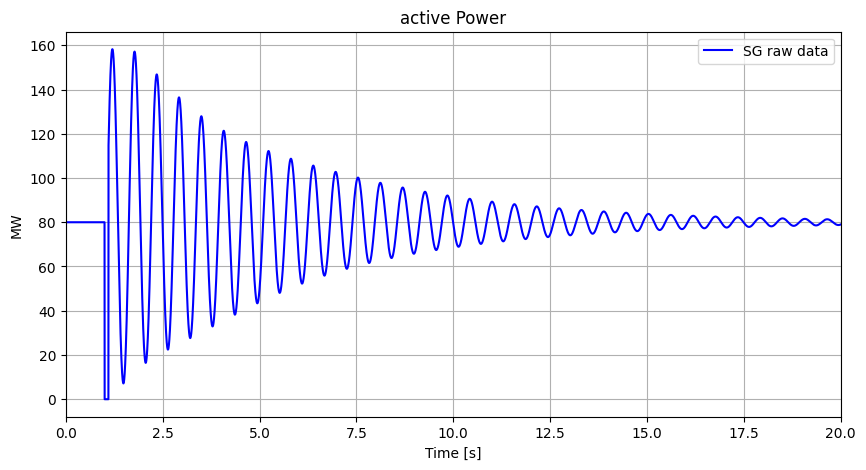

Voltage band [0.9799695768077307,1.0199695768077306] p.u.
Active Power band: 78.33531670176608,81.53267656714429 MW
Reactive Power band: -2.9768971676107965,3.0231028323892035 MVAr
Min Voltage: 0.0
Recovery Voltage time: 3.2952 with Vss: 0.9999695768077307
Ts Power : 17.9792, Pss: 79.93399663445518, P0: 80.0,deltaP: -0.066003365544816
Positive Sequence current Maximum: 5.0636
Max Reactive Power: 23.5382 MVAr
Ts Reactive Power : 10.2052, Qss: 0.02310283238920362 Q0: 0.0,deltaQ: 0.02310283238920362


In [8]:
tech = "SG"
three_phsc = three_ph_scs[(tech,"E2_3PhSC")]
SMA_100 = to_10Hz_reporting_rate(three_phsc)
three_phsc_100 = to_10Hz_reporting_rate(three_phsc)
t1 = get_series(three_phsc,colmap,"t")
V1 = get_series(three_phsc,colmap,"P")
t2 = get_series(three_phsc_100,colmap,"t")
V2 = get_series(three_phsc_100,colmap,"V")
plt.figure(figsize=(10,5))
plt.plot(t1,V1,color = "blue", label = tech + " raw data")
#plt.plot(t2, V2, color='red', label=tech + " 100ms sample")
plt.xlim(0,20)
#plt.ylim(0,82)
plt.xlabel("Time [s]")
plt.title("active Power")
plt.ylabel("MW")
plt.legend()
plt.grid(True)
plt.show()

v_min = kpi_Vmin_fault(three_phsc,colmap)
Ts,Vss= kpi_V_recovery_time(three_phsc,colmap,1.1,0.98,2,20)

ipos = kpi_Ipos_max(three_phsc,colmap)
deltaP,P0,Tsp,Pss = kpi_P_recovery_time(three_phsc,colmap,
                             t_clear = 1.1,t_end = 20,tail_s=3,ripple= 0.1,stat="mean",
                             band = 0.02,drift=0.2)
Qmax = kpi_Q_max(three_phsc,colmap)

deltaQ,Q0,Qss,Tsq = kpi_Q_recovery_time(three_phsc,colmap,t_clear=1.1,t_end=20,
                              tail_s=3,ripple=1,drift=0.2,stat="mean",band=3)
print(f"Min Voltage: {v_min}")
print(f"Recovery Voltage time: {Ts} with Vss: {Vss}")
print(f"Ts Power : {Tsp}, Pss: {Pss}, P0: {P0},deltaP: {deltaP}")
print(f"Positive Sequence current Maximum: {ipos}")
print(f"Max Reactive Power: {Qmax} MVAr")
print(f"Ts Reactive Power : {Tsq}, Qss: {Qss} Q0: {Q0},deltaQ: {deltaQ}")

In [9]:
rows = []
for (technology,fault), df in loadsteps.items():
    df_100 = to_10Hz_reporting_rate(df)
    Ts,fss = kpi_f_setlting_time(df_100,colmap,band = 0.01,t_event=1)
    f_nadir = kpi_f_nadir(df_100,colmap,0,20)
    f_overshoot = kpi_f_overshoot(df_100,colmap,1,20)
    delta_fss = kpi_delta_fss(fss)
    rocof,dfdt,trocof = kpi_rocof_sliding(df_100,colmap,window_s= 0.5)
    deltaP,Pss,P0 = kpi_delta_P(df_100,colmap,t_event=1)
    P_max = kpi_P_max(df_100,colmap,t_event=1,P0 = P0)
    row = {"Technology" : technology, "f nadir [Hz]": f_nadir,
           "Rocof [Hz/s]":rocof,"Steady State frequency [Hz]":fss,
           "f settling time [s]": Ts, 
           "f max overshoot [Hz]":f_overshoot,"delta f [Hz]":delta_fss,
           "Change in Active Power [MW]": deltaP,"Max change in Active Power [MW]":P_max
           }
    rows.append(row)
    # plot_signal_from_df(df_100,colmap,"t","f","Frequency [Hz]","Hz",technology)
    # plot_signal_from_df(df,colmap,"t","P","Active Power","MW",technology)
    # plot_signal(trocof,dfdt,"RoCoF","Hz/s",technology)
    
loadstep_analysis = pd.DataFrame(rows)
loadstep_analysis.head()

Frequency band [49.96389999999999,49.983899999999984]
Frequency band [49.96434666666668,49.984346666666674]
Frequency band [49.961700000000015,49.98170000000001]
Frequency band [49.96096666666665,49.980966666666646]
Frequency band [49.961833333333345,49.98183333333334]
Frequency band [49.96389354838709,49.98389354838709]
Frequency band [49.96389999999999,49.983899999999984]


,Technology,f nadir [Hz],Rocof [Hz/s],Steady State frequency [Hz],f settling time [s],f max overshoot [Hz],delta f [Hz],Change in Active Power [MW],Max change in Active Power [MW]
0,GFL_IEC,49.9282,0.076877,49.973900,5.7982,50.000,-0.0261,0.000100,0.0010
1,GFL_WECC,49.8616,0.150792,49.974347,11.0955,50.039,-0.0257,0.000000,7.2027
2,GFM_Droop,49.9176,0.087515,49.971700,5.8982,50.000,-0.0283,-0.001087,0.1080
3,GFM_VSM,49.9117,0.056604,49.970967,6.5982,50.000,-0.0290,-0.069197,2.4400
4,SG,49.9222,0.064231,49.971833,6.2982,50.000,-0.0282,0.046130,2.0958


In [10]:
rows = []
for (technology,fault), df in three_ph_scs.items():
    Vdip = kpi_Vmin_fault(df,colmap)
    Tsv,Vss = kpi_V_recovery_time(df,colmap,t_clear=1.1,Vthr=0.97,tail_s=3,t_end=20,
                                 drift = 0.002,ripple=0.01)
    Ipos = kpi_Ipos_max(df,colmap)
    Pmin = kpi_Pmin_fault(df,colmap)
    deltaP,P0,Tsp,Pss = kpi_P_recovery_time(df,colmap,t_clear = 1.1,t_end = 20, tail_s=3,
                                  ripple=0.1,drift =0.2,band = 0.02,stat = "mean") 
    Qmax = kpi_Q_max(df,colmap)
    deltaQ,Q0,Tsq,Qss = kpi_Q_recovery_time(df,colmap,t_clear=1.1,t_end=20,
                              tail_s=3,ripple=1,drift=0.2,stat="mean",band=3)
    

    row = {"Technology" : technology, "Voltage_dip_pu": Vdip,
           "Voltage_Settling_time_s":Tsv,"Steady_State_Voltage_pu":Vss,
           "Ipos_max_pu":Ipos,
           "P_min": Pmin, 
           "P_Settling_time_s":Tsp,"Steady_State_Power_MW":Pss,
           "Delta P_MW":deltaP,
           "Q_max_MVAr":Qmax,"Q_Settling_time_s":Tsq,"delta_Q_MW":deltaQ,
           "Steady_State_Reactive_Power_MVAr":Qss
           }
    rows.append(row)
    # plot_signal_from_df(df,colmap,"t","V","Voltage","p.u.",technology)
    # plot_signal_from_df(df,colmap,"t","P","Active Power","MW",technology)
    # plot_signal_from_df(df,colmap,"t","Q","Reactive Power","MVAr",technology)
    
three_phsc_analysis = pd.DataFrame(rows)
three_phsc_analysis.head()

Voltage band [0.9706827724091971,1.0306827724091971] p.u.
Active Power band: 79.16360603998666,82.39477363345551 MW
Reactive Power band: -2.9977647117627457,3.0022352882372543 MVAr
Voltage band [0.97,1.03] p.u.
Active Power band: 78.4,81.6 MW
Reactive Power band: -3.0,3.0 MVAr
Voltage band [0.9697,1.0297] p.u.
Active Power band: 77.902579038987,81.08227614261912 MW
Reactive Power band: -2.8242331556147953,3.1757668443852047 MVAr
Voltage band [0.97,1.03] p.u.
Active Power band: 78.47049135754749,81.67336855581475 MW
Reactive Power band: -2.997091702765745,3.002908297234255 MVAr
Voltage band [0.9699695768077307,1.0299695768077308] p.u.
Active Power band: 78.33531670176608,81.53267656714429 MW
Reactive Power band: -2.9768971676107965,3.0231028323892035 MVAr
Voltage band [0.97,1.03] p.u.
Active Power band: 78.4392,81.64080000000001 MW
Reactive Power band: -2.999918216682646,3.000081783317354 MVAr
Voltage band [0.97,1.03] p.u.
Active Power band: 78.4,81.6 MW
Reactive Power band: -2.99992320

,Technology,Voltage_dip_pu,Voltage_Settling_time_s,Steady_State_Voltage_pu,Ipos_max_pu,P_min,P_Settling_time_s,Steady_State_Power_MW,Delta P_MW,Q_max_MVAr,Q_Settling_time_s,delta_Q_MW,Steady_State_Reactive_Power_MVAr
0,GFL_IEC,0.0,0.4371,1.000683,1.0477,0.2818,0.7701,80.779190,0.779190,116.0208,0.002235,0.002235,1.0531
1,GFL_WECC,0.0,1.4897,1.000000,2.6437,-8.5597,5.7890,80.000000,0.000000,408.5762,0.000000,0.000000,1.2137
2,GFM_Droop,0.0,0.1522,0.999700,1.9853,-84.1866,6.0662,79.492428,-0.607572,83.3249,0.175767,0.175767,1.7222
3,GFM_VSM,0.0,0.0492,1.000000,1.8931,0.9842,4.3422,80.071930,-0.028070,88.0137,0.002908,0.002908,1.8212
4,SG,0.0,0.4262,0.999970,5.0636,0.0000,17.9792,79.933997,-0.066003,23.5382,0.023103,0.023103,10.2052


7


# Generate Plots

Once the analysis is performed relevant images are to be created in order to facilitate comparisons

In [112]:
import math
import matplotlib.pyplot as plt

def plot_metric_grid(
    data_dict: dict,
    colmap: dict,
    y_key: str,
    title: str,
    y_label: str = "",
    x_label: str = "Time [s]",
    xlim: tuple | None = None,
    ylim:tuple | None = None,
    yticks:tuple |None = None,
    cols: int = 2,
    figsize_per_row: float = 2.5
):
    """
    Plots one metric (y_key) vs time for each entry in a dict of DataFrames.

    data_dict: {(tech, case): df, ...} or {key: df, ...}
    y_key: key used in get_series(df, colmap, y_key) e.g. "V", "f", "P"
    xlim: (xmin, xmax) e.g. (0, 5)
    cols: number of columns in grid
    """
    keys = list(data_dict.keys())
    nplots = len(keys)
    rows = math.ceil(nplots / cols)

    fig, axs = plt.subplots(rows, cols, figsize=(8, figsize_per_row * rows), sharex=False)
    axs = axs.flatten()

    for i, key in enumerate(keys):
        # Support tuple keys (tech, case) or simple keys
        if isinstance(key, tuple) and len(key) >= 2:
            tech, case = key[0], key[1]
        else:
            tech, case = str(key), None

        df = data_dict[key]
        t = get_series(df, colmap, "t")
        y = get_series(df, colmap, y_key)

        axs[i].plot(t, y)

       
        axs[i].set_title(f"{tech}")
        axs[i].set_xlabel(x_label)
        axs[i].set_ylabel(y_label)
        axs[i].grid(True)


        if xlim is not None:
            axs[i].set_xlim(xlim)
            
        if ylim is not None:
            axs[i].set_ylim(ylim)
        
        if yticks is not None:
            axs[i].set_yticks(np.arange(*yticks))


    # delete unused axes
    for j in range(nplots, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


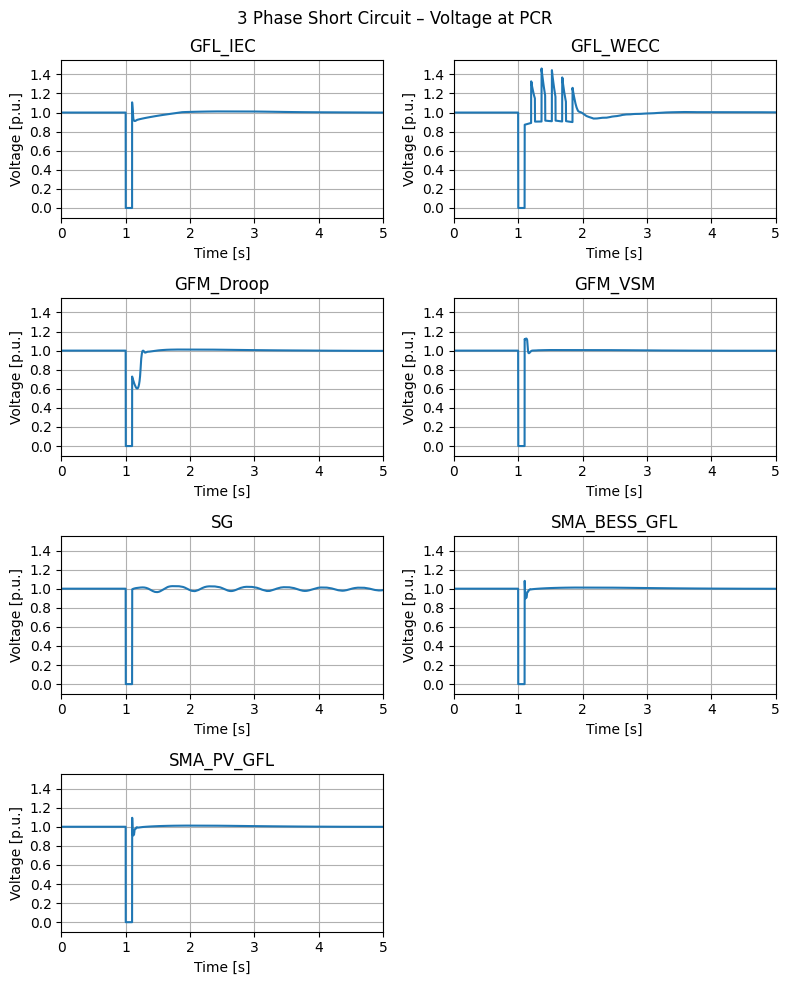

In [116]:
plot_metric_grid(
    data_dict=three_ph_scs,
    colmap=colmap,
    y_key="V",
    title="3 Phase Short Circuit – Voltage at PCR",
    y_label="Voltage [p.u.]",
    xlim=(0, 5),
    ylim=(-0.1,1.55),
    yticks=(0,1.6,0.2),
    cols=2
)


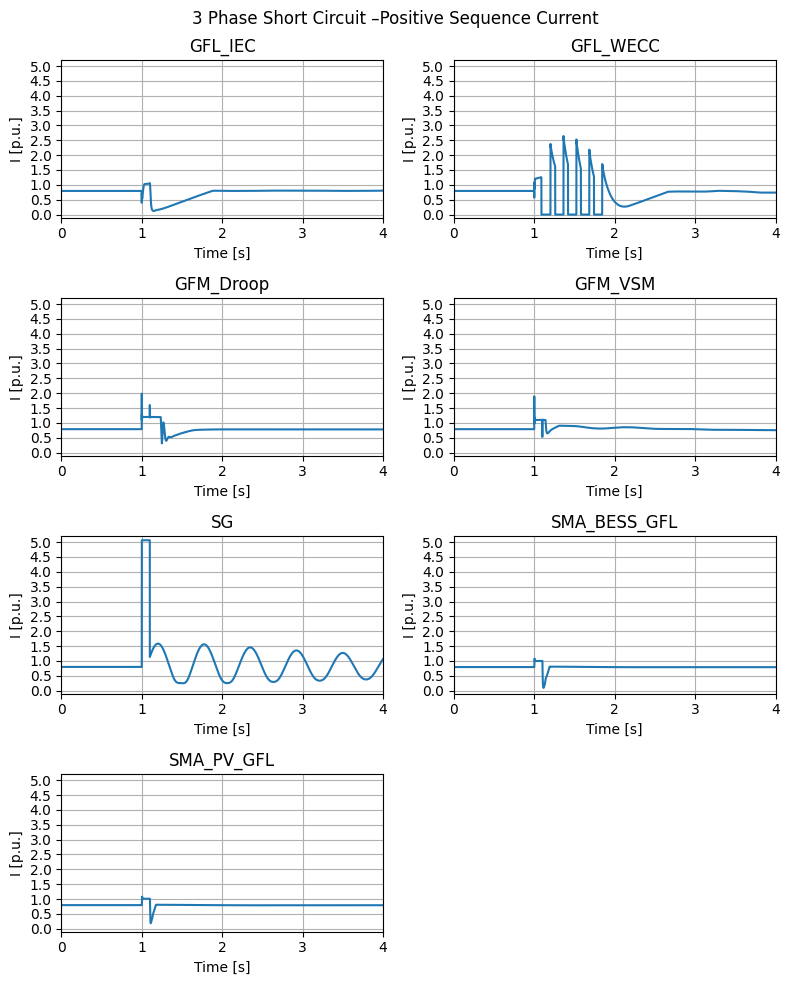

In [115]:
plot_metric_grid(
    data_dict=three_ph_scs,
    colmap=colmap,
    y_key="Ipos",
    title="3 Phase Short Circuit –Positive Sequence Current",
    y_label="I [p.u.]",
    xlim=(0, 4),
    ylim=(-0.1,5.2),
    yticks=(0,5.5,0.5),
    cols=2
)

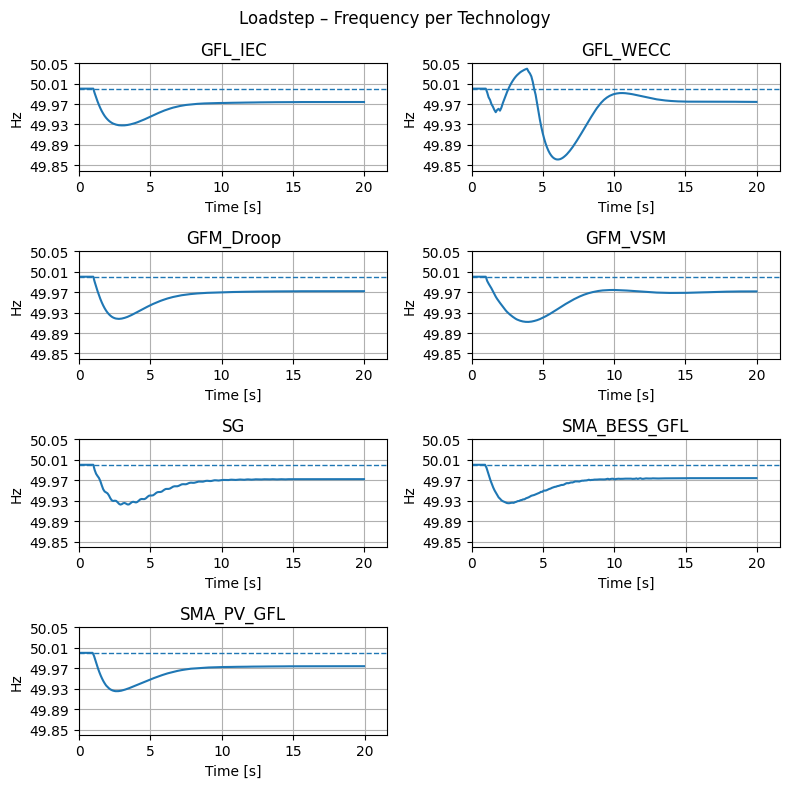

In [ ]:

keys = list(loadsteps.keys())
n = n = (len(keys) + 1) // 2

fig, axs = plt.subplots(n, 2, figsize=(8, 2*n), sharex=False)
axs = axs.flatten()

# If only 1 tech, axs is not iterable → fix:
if n == 1:
    axs = [axs]

for i, key in enumerate(keys):
    tech,case = key
    df = loadsteps[key]
    df = to_10Hz_reporting_rate(df)
    axs[i].plot(df["Time in s"],df["Electrical Frequency in Hz"])
    axs[i].set_title(tech)
    axs[i].set_xlabel("Time [s]")
    axs[i].set_ylabel("Hz")
    axs[i].set_xlim(left=0)
    axs[i].grid(True)
    axs[i].axhline(50, linestyle='--', linewidth=1)
    axs[i].set_yticks(np.arange(49.85,50.1,0.04))
    axs[i].set_ylim(49.84, 50.05)
   
for j in range(len(keys), len(axs)):
    fig.delaxes(axs[j])

axs[-1].set_xlabel("Time [s]")
fig.suptitle("Loadstep – Frequency per Technology")

plt.tight_layout()
plt.show()


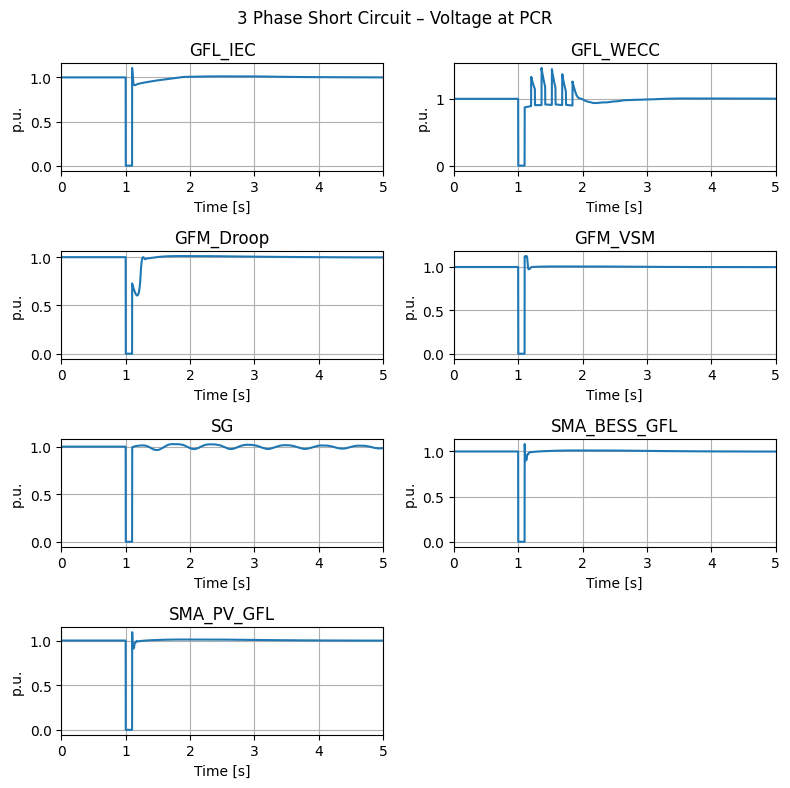

In [55]:
keys = list(three_ph_scs.keys())
n = n = (len(keys) + 1) // 2

fig, axs = plt.subplots(n, 2, figsize=(8, 2*n), sharex=False)
axs = axs.flatten()

# If only 1 tech, axs is not iterable → fix:
if n == 1:
    axs = [axs]

for i, key in enumerate(keys):
    tech,case = key
    df = three_ph_scs[key]
    t = get_series(df,colmap,"t")
    V = get_series(df,colmap,"V")
    axs[i].plot(t,V)
    axs[i].set_title(tech)
    axs[i].set_xlabel("Time [s]")
    axs[i].set_ylabel("p.u.")
    axs[i].set_xlim(left=0)
    axs[i].grid(True)
    # axs[i].axhline(50, linestyle='--', linewidth=1)
    # axs[i].set_yticks(np.arange(49.85,50.1,0.04))
    # axs[i].set_ylim(49.84, 50.05)
    axs[i].set_xlim(0,5)
   
for j in range(len(keys), len(axs)):
    fig.delaxes(axs[j])

axs[-1].set_xlabel("Time [s]")
fig.suptitle("3 Phase Short Circuit – Voltage at PCR")

plt.tight_layout()
plt.show()


In [47]:
print(
    loadstep_analysis.to_string(
        index=False,
        justify="center",
        float_format="{:.3f}".format
    )
)


 Technology   f nadir [Hz]  Rocof [Hz/s]  Steady State frequency [Hz]  f settling time [s]  f max overshoot [Hz]  delta f [Hz]  Change in Active Power [MW]  Max change in Active Power [MW]
     GFL_IEC     49.928        0.077                49.974                    5.798                50.000            -0.026                0.000                         0.001              
    GFL_WECC     49.862        0.151                49.974                   11.095                50.039            -0.026                0.000                         7.203              
   GFM_Droop     49.918        0.088                49.972                    5.898                50.000            -0.028               -0.001                         0.108              
     GFM_VSM     49.912        0.057                49.971                    6.598                50.000            -0.029               -0.069                         2.440              
          SG     49.922        0.064                49.

In [ ]:
print(
    three_phsc_analysis.to_string(
        index=False,
        justify="center",
        float_format="{:.3f}".format
    )
)
